In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy

In [127]:
mu_true = 1
sigma_true = 0.2

distG = norm(loc = mu_true, scale=sigma_true)

[]

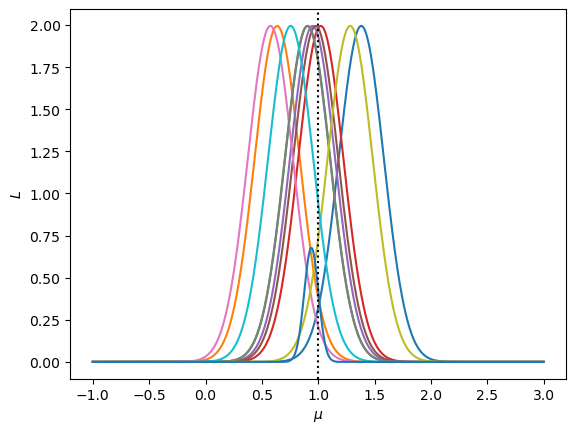

In [128]:
N = 10
data = distG.rvs(N)
for i in data:
    # Scan across 1000 possible mu values from 3 to 20.
    mu_proposed = np.linspace(mu_true-2,mu_true+2,1000)
    
    # compute the lnL for each possible mu.
    L_scan = []
    for mu in mu_proposed:
        L_temp = norm.pdf(i, loc=mu, scale=sigma_true) # gives you the log prob. density; useful!
        L_temp = np.sum(L_temp) # sum over the log pmf of all data points
        L_scan.append(L_temp)
        
    # convert to numpy array
    L_scan = np.array(L_scan)
    if i == data[0] : L_tot = L_scan
    else : L_tot = L_tot*L_scan
        
    # mu_proposed that maximizes the lnL.
    plt.plot(mu_proposed,L_scan)
    
    #findmax = mu_proposed[np.argmax(L_scan)]
    
plt.plot(mu_proposed,L_tot)
plt.axvline(mu_true,c='black',ls='dotted')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$L$')
plt.plot()

0.937937937937938


[]

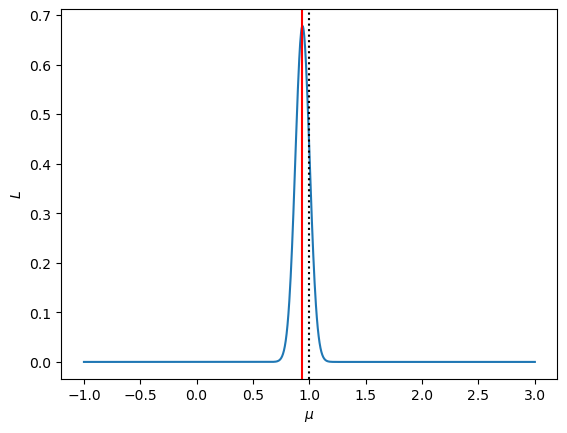

In [129]:

plt.plot(mu_proposed,L_tot)
    
findmax = mu_proposed[np.argmax(L_tot)]
print(findmax)
plt.axvline(findmax,c='red')
    
plt.axvline(mu_true,c='black',ls='dotted')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$L$')
plt.plot()

In [114]:
diff = np.diff(np.log(L_tot), n=2)
delta_mu = (mu_proposed[1]-mu_proposed[0]) #delta viene dall'asse di mu testate
sigma_f = 1/np.sqrt(-diff[np.argmax(L_tot)]/delta_mu**2)
print("Fisher matrix error on estimated mean is", sigma_f)


sigma_ml = sigma_true/np.sqrt(N)
print("Fisher matrix error", sigma_ml)

Fisher matrix error on estimated mean is 0.06324555320335784
Fisher matrix error 0.06324555320336758


[]

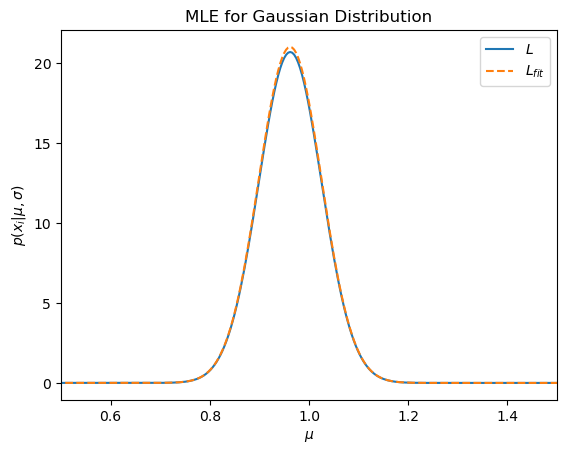

In [122]:
plt.plot(mu_proposed,L_tot,label=r'$L$')

L_fit = norm.pdf(mu_proposed,loc=findmax,scale=sigma_ml) / 0.3 # la normalizzazione è scelta ad hoc
plt.plot(mu_proposed,L_fit,linestyle='--',label=r'$L_{fit}$')

plt.xlim(mu_true-0.5,mu_true+0.5)
plt.xlabel('$\mu$') #Leave out or adjust if no latex
plt.ylabel(r'$p(x_i|\mu,\sigma)$') #Leave out or adjust if no latex
plt.title('MLE for Gaussian Distribution')
plt.legend()
plt.plot()